In [2]:
import pandas as pd
data_ancfcc = pd.read_csv("scrapping/data/data_ancfcc.csv")

In [3]:
import numpy as np

data_ancfcc['property_type'] = np.where(
    data_ancfcc['Consistance'].str.contains('Terrain', case=False, na=False), 'Terrain',
    np.where(
        data_ancfcc['Consistance'].str.contains('Appartement', case=False, na=False), 'Appartement',
        np.where(
            data_ancfcc['Consistance'].str.contains('Villa', case=False, na=False), 'Villa',
            'Autre'
        )
    )
)
data_ancfcc = data_ancfcc[~data_ancfcc['property_type'].isin(['Autre', 'Terrain'])]
data_ancfcc['property_type'].value_counts()

property_type
Villa          258
Appartement    153
Name: count, dtype: int64

In [4]:
import re

def decode_ancfcc(code):
    if not isinstance(code, str):
        return None

    macro_decoder = {
        "CS": "Casablanca Sud",
        "CN": "Casablanca Nord",
        "CC": "Casablanca Centre",
        "CE": "Casablanca Est"
    }

    zone_decoder = {
        "AC": "Aïn Chock",
        "AS": "Aïn Sebaâ",
        "HM": "Hay Mohammadi",
        "RN": "Sidi Moumen",
        "HH": "Hay Hassani",
        "SB": "Sidi Bernoussi",
        "SO": "Sidi Othman",
        "MR": "Moulay Rachid",
        "BM": "Ben M'sik",
        "MA": "Maârif",
        "MS": "Mers Sultan",
        "AF": "Al Fida",
        "DB": "Dar Bouazza",
        "OA": "Oasis"
    }

    code = code.upper()

    # 🔹 extraire macro
    macro = code.split("-")[0]

    # 🔹 extraire partie droite
    part = code.split("-")[1]

    # 🔹 extraire zone (2 lettres)
    zone_match = re.match(r'[A-Z]{2}', part)
    zone = zone_match.group() if zone_match else None

    # 🔹 numéro
    num = re.search(r'\d+', part)
    num = num.group() if num else None

    # 🔹 suffixe
    suffix = None
    if "BIS" in part:
        suffix = "BIS"
    elif "TER" in part:
        suffix = "TER"
    elif "QI" in part:
        suffix = "Quartier Industriel"

    return {
        "macro_zone": macro_decoder.get(macro),
        "arrondissement": zone_decoder.get(zone),
        "zone_code": zone,
        "sector": num,
        "subdivision": suffix
    }


In [5]:
data_ancfcc_decoded = data_ancfcc["Zone"].apply(decode_ancfcc).apply(pd.Series)
data_ancfcc = pd.concat([data_ancfcc, data_ancfcc_decoded], axis=1)

In [6]:
Q1 = data_ancfcc["Valeur en DH/m²"].quantile(0.25)
Q3 = data_ancfcc["Valeur en DH/m²"].quantile(0.75)

IQR = Q3 - Q1

df_clean = data_ancfcc[
    (data_ancfcc["Valeur en DH/m²"] >= Q1 - 1.5 * IQR) &
    (data_ancfcc["Valeur en DH/m²"] <= Q3 + 1.5 * IQR)
]

In [7]:
df_clean.groupby(['property_type','arrondissement'])['Valeur en DH/m²'].mean()

property_type  arrondissement
Appartement    Al Fida           11222.222222
               Aïn Chock         15033.333333
               Aïn Sebaâ         11090.909091
               Ben M'sik          9500.000000
               Hay Hassani       13653.846154
               Hay Mohammadi      9800.000000
               Maârif            18863.636364
               Mers Sultan       14111.111111
               Moulay Rachid      6708.333333
               Sidi Bernoussi    10000.000000
               Sidi Moumen       13125.000000
               Sidi Othman       10166.666667
Villa          Al Fida            8000.000000
               Aïn Chock         10282.608696
               Aïn Sebaâ          5839.285714
               Ben M'sik          6500.000000
               Hay Hassani       10550.000000
               Hay Mohammadi      5865.384615
               Maârif            10800.000000
               Mers Sultan        7833.333333
               Moulay Rachid      6375.000000
    

In [ ]:
df = df_clean.groupby(['property_type','arrondissement'])['Valeur en DH/m²'].mean()
df.to_csv("data_ancfcc_grouped_arrondissement.csv")

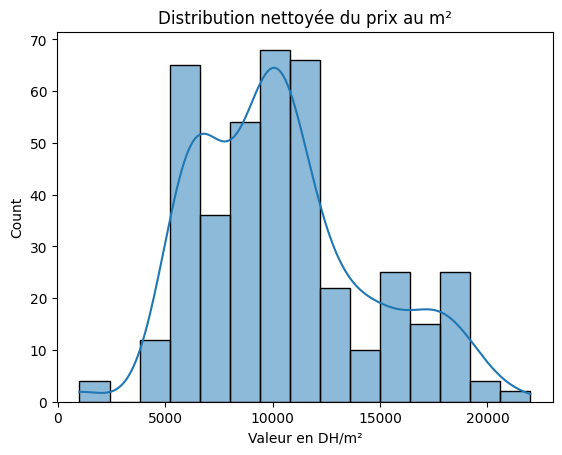

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df_clean["Valeur en DH/m²"], kde=True)
plt.title("Distribution nettoyée du prix au m²")
plt.show()